In [1]:
import os
os.chdir('..')

In [2]:
import pandas as pd

# Load train and test datasets from the project's raw_data folder
train = pd.read_csv('raw_data/train.csv')
test = pd.read_csv('raw_data/test.csv')

df = train.copy() 

# Check the dimensions of both datasets (rows, columns)
print(train.shape)
print(test.shape)

# Preview the first 5 rows of the training set
train.head()


(80000, 41)
(20000, 40)


,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [3]:
import os
print(os.getcwd())
print(os.listdir('.'))  # see what's actually here

/Users/francescosias/code/francescosias/MarathonIQ
['.DS_Store', 'raw_data', 'README.md', '.gitignore', '.python-version', '.ipynb_checkpoints', 'Notebook', '.git']


In [4]:
# Check column names and data types
print(train.dtypes)

runner_id                          object
age                                 int64
gender                             object
running_experience_months           int64
previous_marathon_count             int64
training_program                   object
motivation_level                    int64
personal_best_minutes             float64
weekly_mileage_km                 float64
weekly_mileage_miles              float64
runs_per_week                       int64
long_run_distance_km              float64
speed_work_sessions_per_week        int64
rest_days_per_week                  int64
training_adherence_pct              int64
consecutive_weeks_no_miss           int64
cross_training_hours_per_week     float64
resting_heart_rate_bpm              int64
vo2_max                           float64
bmi                               float64
recovery_score                    float64
sleep_hours_avg                   float64
injury_count                        int64
injury_severity                   

In [5]:
# Check for missing values in each column
train.isnull().sum().sort_values(ascending=False)

injury_severity                   47350
personal_best_minutes             10745
vo2_max                            9611
cross_training_hours_per_week      7983
nutrition_score                    6402
hydration_consistency              6402
sleep_hours_avg                    3942
actual_finish_time_minutes         1989
weather_condition_training_pct        0
training_streak_days                  0
missed_workout_pct                    0
early_morning_run_frequency           0
runner_id                             0
goal_completion_rate                  0
warmup_adherence_pct                  0
stretching_adherence_pct              0
marathon_date                         0
marathon_weather                      0
course_difficulty                     0
target_finish_time_minutes            0
mental_preparation_score              0
run_club_attendance_rate              0
recovery_score                        0
injury_count                          0
age                                   0


In [6]:
# Summary statistics for all numeric columns
train.describe()

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,...,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
count,80000.000000,80000.000000,80000.000000,80000.000000,69255.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,78011.000000,80000.000000,80000.000000
mean,41.538412,36.147413,2.004700,5.505575,259.321580,29.940183,17.225917,4.356975,15.828567,0.978862,...,34.382600,29.235175,64.490900,40.010475,60.272625,52.179725,249.308687,287.931407,6.372187,0.450000
std,13.848164,35.453932,1.419094,2.871288,33.778153,17.392518,7.072490,0.896649,2.358518,0.645074,...,24.113435,21.936089,17.171607,28.388266,20.957232,24.647479,30.372115,33.648005,2.067061,0.804679
min,18.000000,6.000000,0.000000,1.000000,132.000000,20.000000,12.400000,3.000000,15.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,171.000000,1.000000,0.000000
25%,30.000000,10.000000,1.000000,3.000000,236.000000,20.000000,12.400000,4.000000,15.000000,1.000000,...,15.000000,11.000000,53.000000,16.000000,46.000000,35.000000,228.000000,265.000000,5.000000,0.000000
50%,42.000000,25.000000,2.000000,6.000000,261.000000,20.600000,12.400000,4.000000,15.000000,1.000000,...,33.000000,28.000000,65.000000,39.000000,61.000000,52.000000,252.000000,290.000000,7.000000,0.000000
75%,54.000000,49.000000,3.000000,8.000000,283.000000,34.300000,20.500000,5.000000,15.000000,1.000000,...,51.000000,45.000000,77.000000,61.000000,75.000000,70.000000,272.000000,313.000000,8.000000,1.000000
max,65.000000,240.000000,11.000000,10.000000,377.000000,119.994348,60.200000,7.000000,41.200000,3.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,350.000000,400.000000,10.000000,3.000000


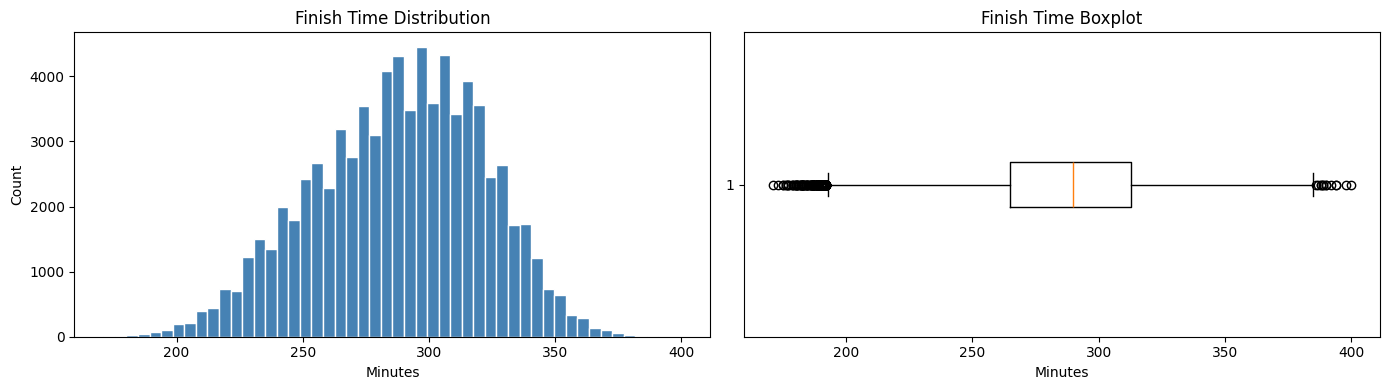

count    78011.000000
mean       287.931407
std         33.648005
min        171.000000
25%        265.000000
50%        290.000000
75%        313.000000
max        400.000000
Name: actual_finish_time_minutes, dtype: float64


In [7]:
import matplotlib.pyplot as plt

# Distribution of our target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(train['actual_finish_time_minutes'].dropna(), bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Finish Time Distribution')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

# Boxplot to spot outliers
axes[1].boxplot(train['actual_finish_time_minutes'].dropna(), vert=False)
axes[1].set_title('Finish Time Boxplot')
axes[1].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

# Key stats
print(train['actual_finish_time_minutes'].describe())


In [8]:
# Check all categorical columns and their unique values
cat_cols = train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n{col} ({train[col].nunique()} unique):")
    print(train[col].value_counts())
    


runner_id (80000 unique):
runner_id
R009432    1
R070522    1
R031755    1
R055310    1
R089689    1
          ..
R016555    1
R055045    1
R059243    1
R008978    1
R072705    1
Name: count, Length: 80000, dtype: int64

gender (3 unique):
gender
Female        38577
Male          38282
Non-binary     3141
Name: count, dtype: int64

training_program (3 unique):
training_program
Beginner        39983
Intermediate    25287
Advanced        14730
Name: count, dtype: int64

injury_severity (3 unique):
injury_severity
Minor       16958
Moderate     9909
Severe       5783
Name: count, dtype: int64

marathon_date (730 unique):
marathon_date
2025-04-17    147
2025-02-03    144
2024-07-02    142
2024-01-21    142
2025-05-17    140
             ... 
2025-04-28     83
2024-09-14     81
2024-04-22     80
2024-08-08     80
2024-04-17     77
Name: count, Length: 730, dtype: int64

marathon_weather (6 unique):
marathon_weather
Cloudy    20054
Sunny     20045
Rainy     11955
Hot       11921
Cold       

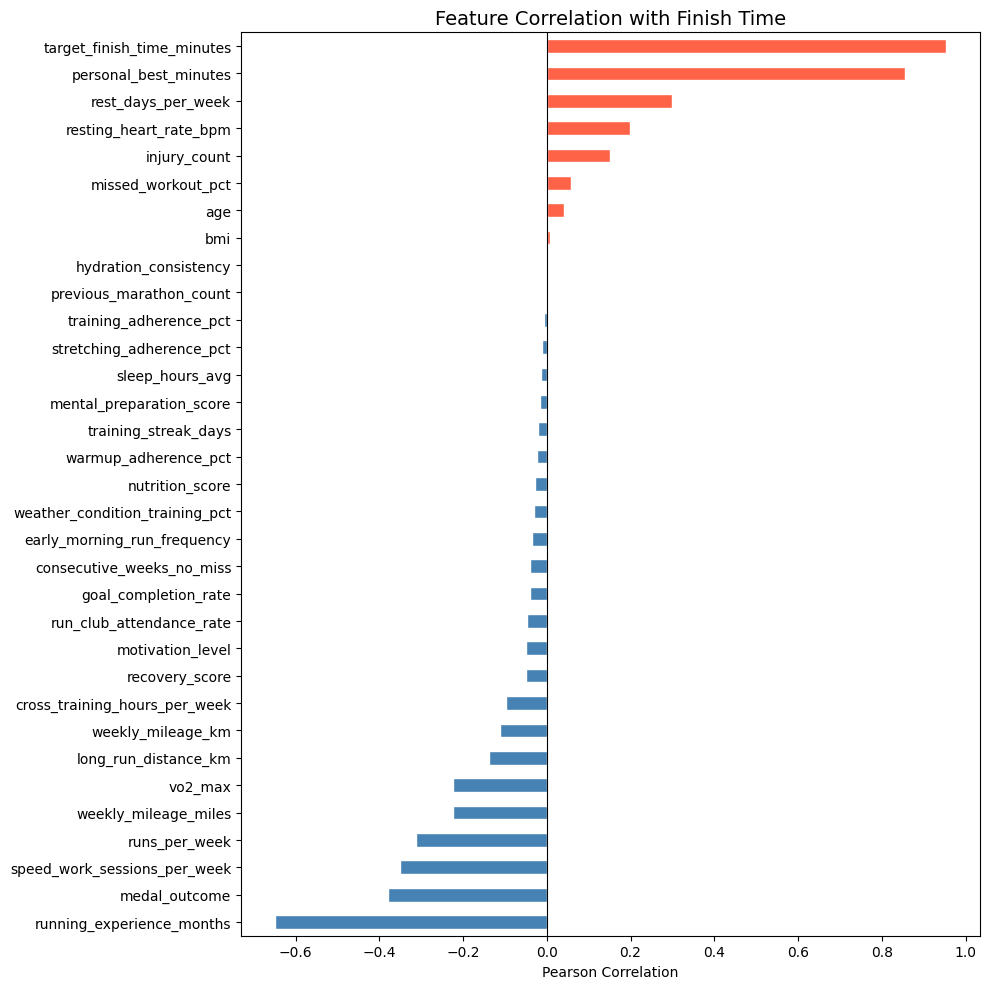

🔴 Top 5 features that INCREASE finish time (slower):
injury_count                  0.150054
resting_heart_rate_bpm        0.198988
rest_days_per_week            0.298383
personal_best_minutes         0.855617
target_finish_time_minutes    0.954332
Name: actual_finish_time_minutes, dtype: float64

🔵 Top 5 features that DECREASE finish time (faster):
running_experience_months      -0.649845
medal_outcome                  -0.379521
speed_work_sessions_per_week   -0.350391
runs_per_week                  -0.311368
weekly_mileage_miles           -0.224848
Name: actual_finish_time_minutes, dtype: float64


In [9]:
# Correlation of all numeric features with the target
corr = (train
        .select_dtypes(include='number')
        .corr()['actual_finish_time_minutes']
        .drop('actual_finish_time_minutes')
        .sort_values())

# Plot as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Finish Time', fontsize=14)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

# Print top 5 positive and negative correlates
print("🔴 Top 5 features that INCREASE finish time (slower):")
print(corr.tail(5))
print("\n🔵 Top 5 features that DECREASE finish time (faster):")
print(corr.head(5))

/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_43899/4104391297.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True)
/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_43899/4104391297.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True)
/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_43899/4104391297.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, vert=True)
/var/folders/y7/380cvp716m9cx5y9my0vhmsw0000gn/T/ipykernel_43899/4104391297.py:13: MatplotlibDeprecatio

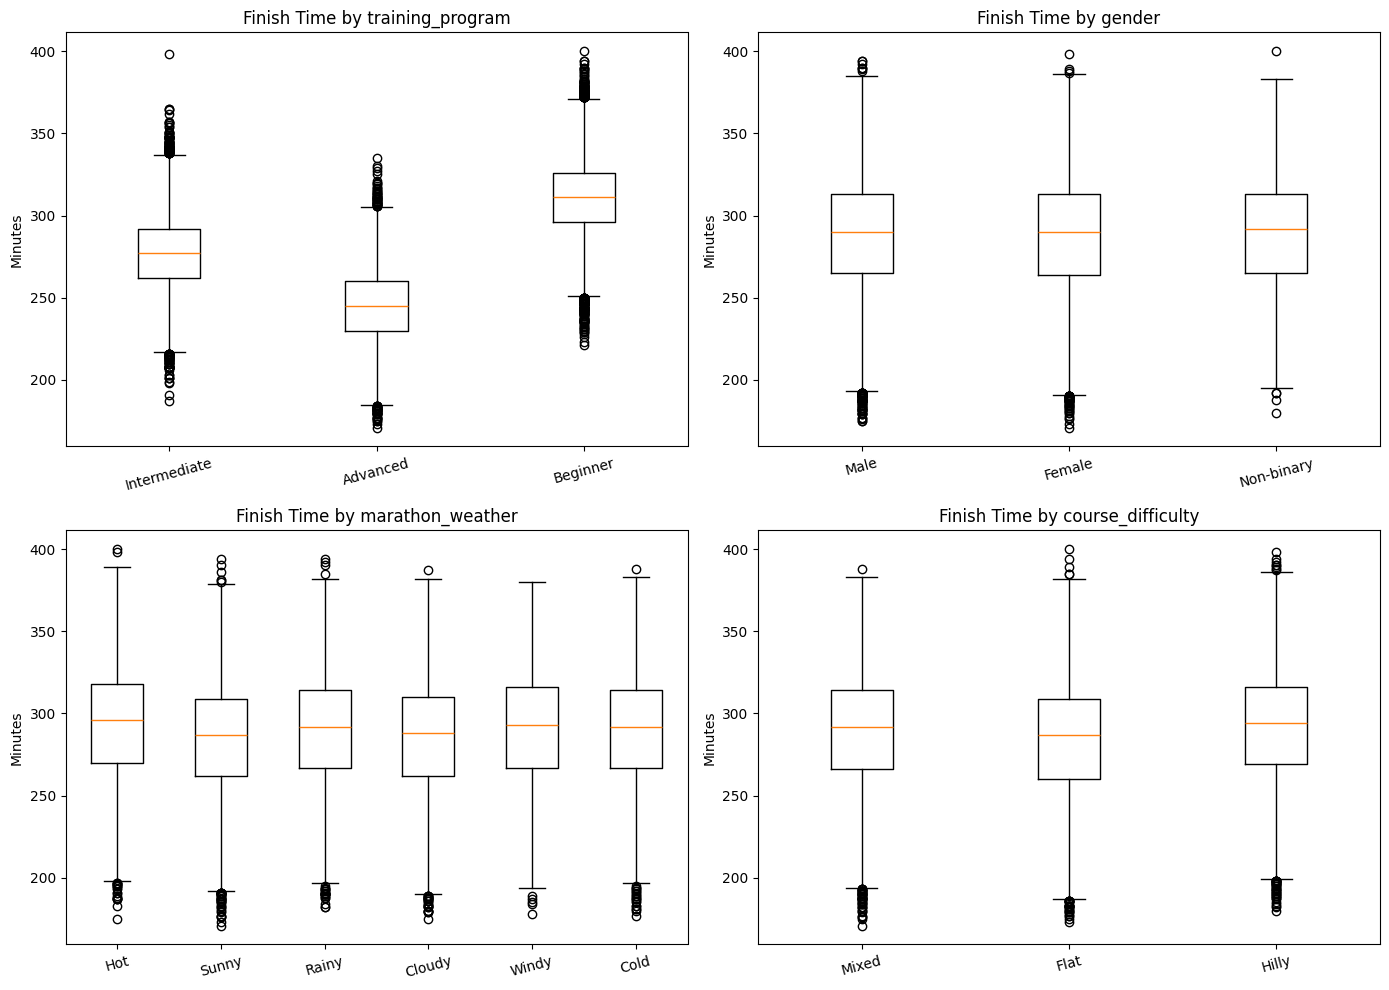

In [10]:
# Boxplots of finish time by categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Finish time by training program (ordinal)
order = ['Beginner', 'Intermediate', 'Advanced']
for i, (col, ax) in enumerate(zip(
    ['training_program', 'gender', 'marathon_weather', 'course_difficulty'],
    axes.flatten()
)):
    groups = [train[train[col] == cat]['actual_finish_time_minutes'].dropna()
              for cat in train[col].unique()]
    labels = train[col].unique()
    ax.boxplot(groups, labels=labels, vert=True)
    ax.set_title(f'Finish Time by {col}')
    ax.set_ylabel('Minutes')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

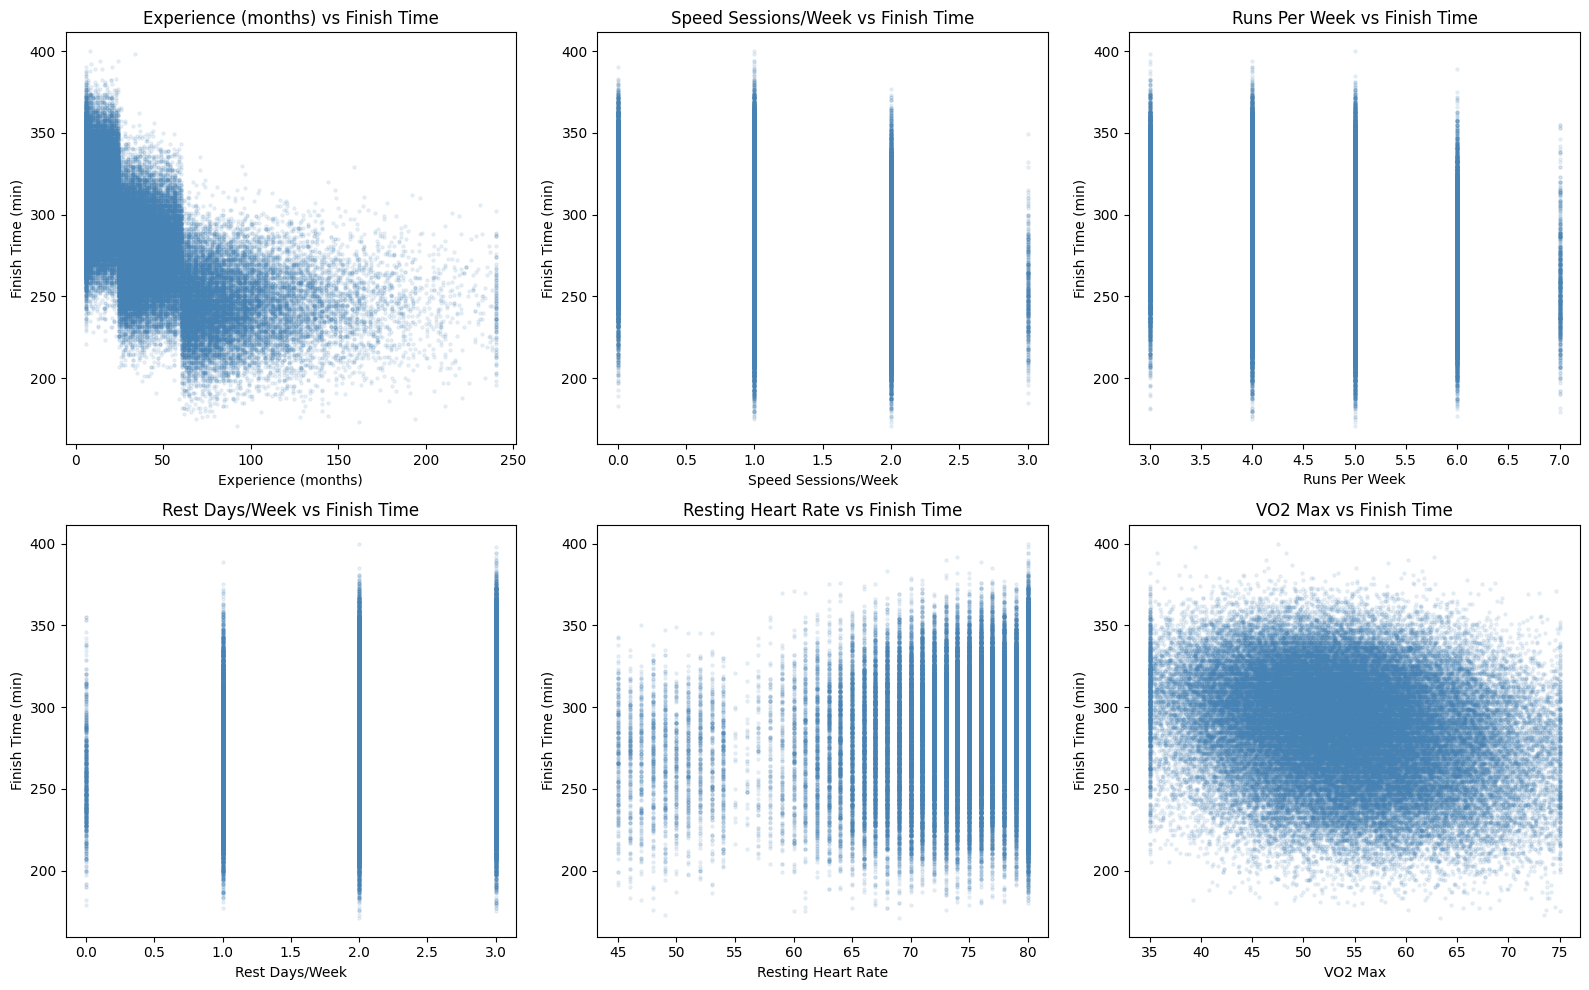

In [11]:
# Scatter plots of the strongest numeric predictors vs finish time
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

pairs = [
    ('running_experience_months', 'Experience (months)'),
    ('speed_work_sessions_per_week', 'Speed Sessions/Week'),
    ('runs_per_week', 'Runs Per Week'),
    ('rest_days_per_week', 'Rest Days/Week'),
    ('resting_heart_rate_bpm', 'Resting Heart Rate'),
    ('vo2_max', 'VO2 Max'),
]

for ax, (col, label) in zip(axes.flatten(), pairs):
    ax.scatter(train[col], train['actual_finish_time_minutes'],
               alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Finish Time (min)')
    ax.set_title(f'{label} vs Finish Time')

plt.tight_layout()
plt.show()


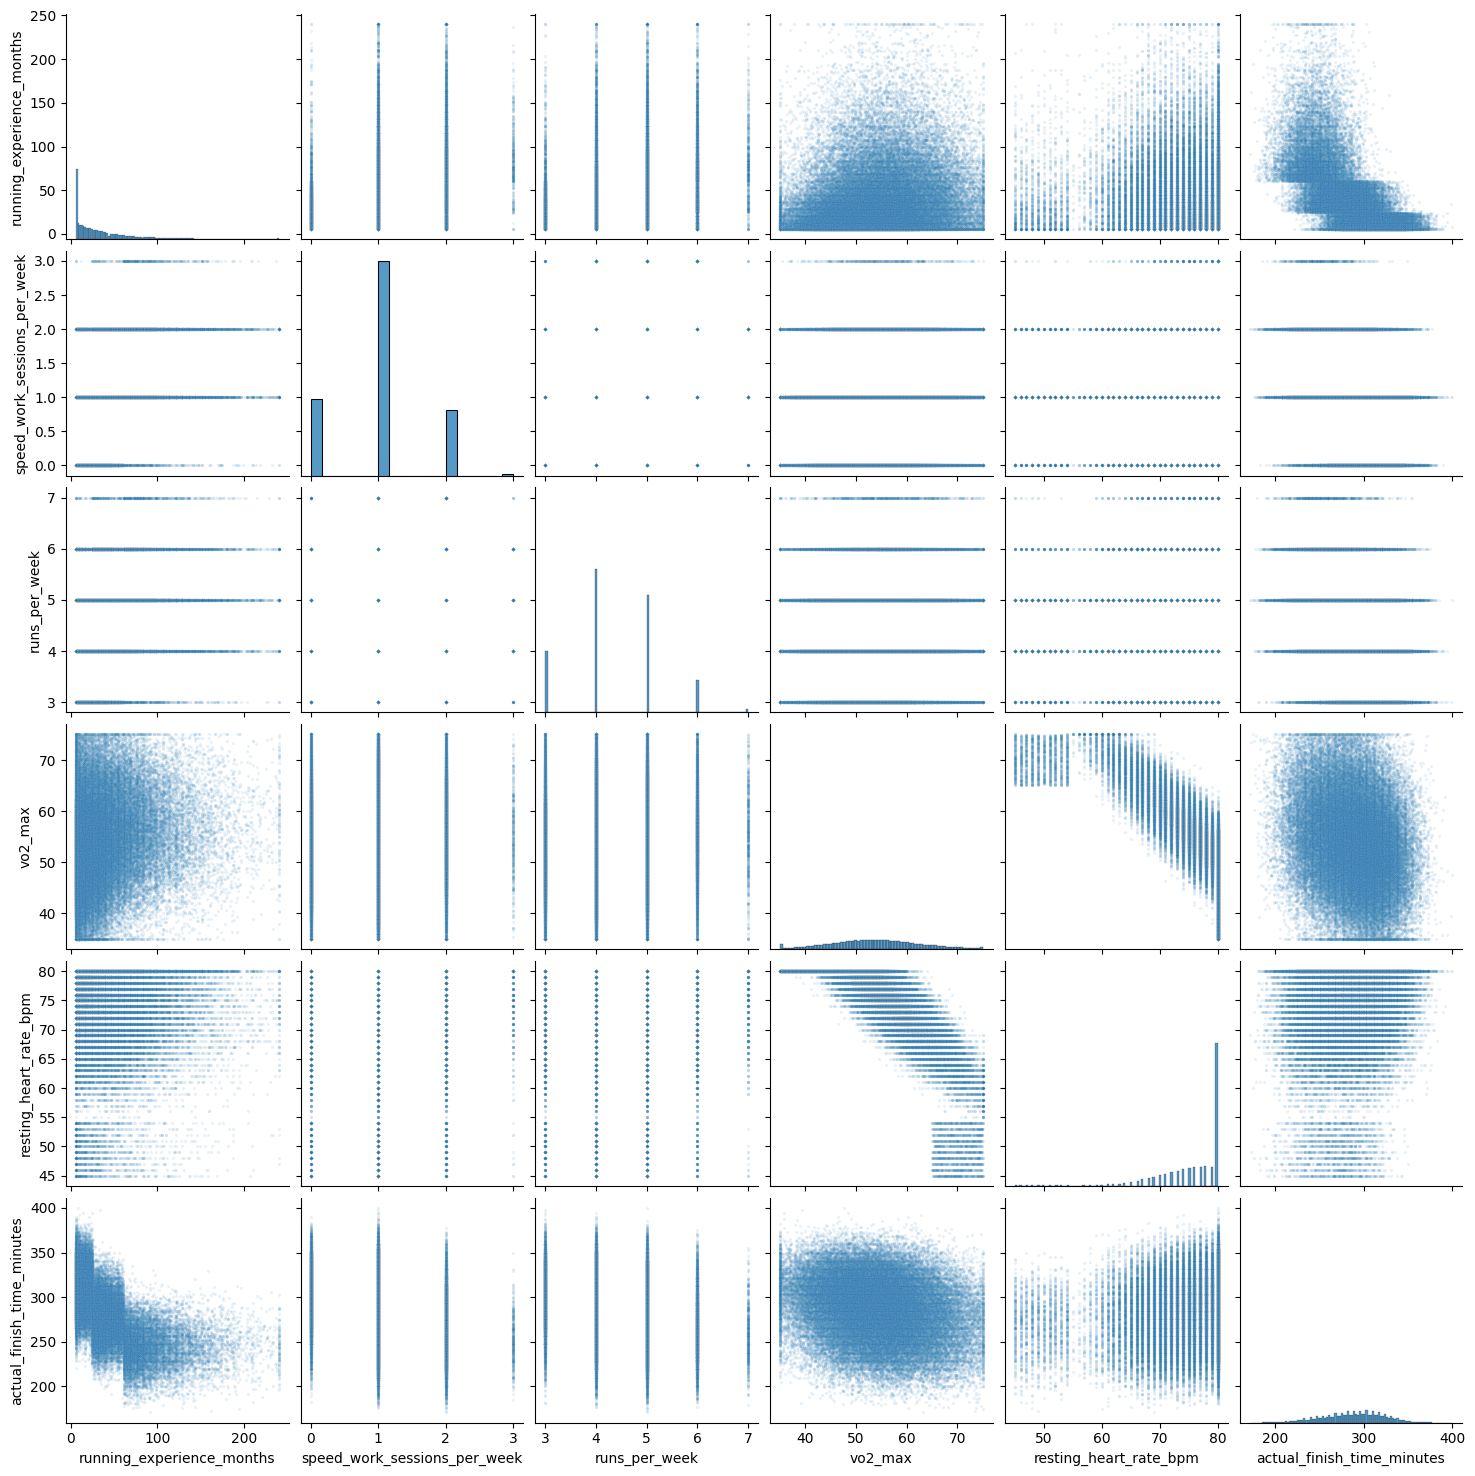

In [12]:
import seaborn as sns

# Pairplot of top numeric predictors
cols = ['running_experience_months', 'speed_work_sessions_per_week',
        'runs_per_week', 'vo2_max', 'resting_heart_rate_bpm', 'actual_finish_time_minutes']

sns.pairplot(train[cols].dropna(), plot_kws={'alpha': 0.1, 's': 5})
plt.show()

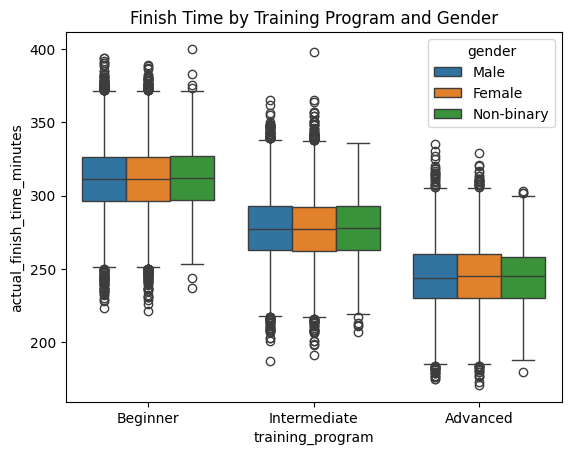

In [13]:
# Does gender interact with training program?
sns.boxplot(data=train, x='training_program', y='actual_finish_time_minutes',
            hue='gender', order=['Beginner', 'Intermediate', 'Advanced'])
plt.title('Finish Time by Training Program and Gender')
plt.show()

In [14]:
# Profile of runners who DNF'd vs finished
train['dnf'] = train['actual_finish_time_minutes'].isna().astype(int)

print(train.groupby('dnf')[['age', 'running_experience_months',
      'injury_count', 'weekly_mileage_km','sleep_hours_avg']].mean())

           age  running_experience_months  injury_count  weekly_mileage_km  \
dnf                                                                          
0    41.478458                  36.349515      0.537270          29.881945   
1    43.889894                  28.220714      1.122172          32.224360   

     sleep_hours_avg  
dnf                   
0           6.968094  
1           6.881488  


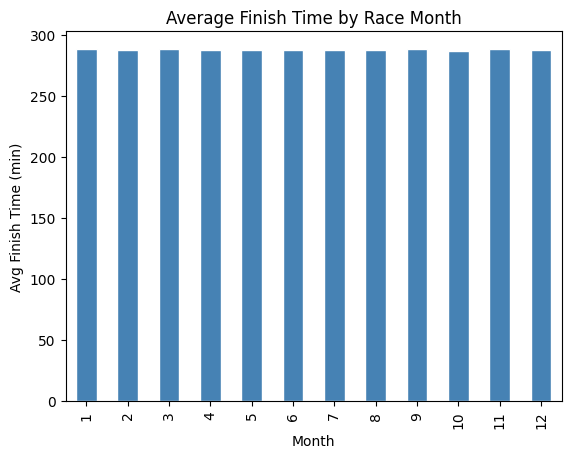

In [15]:
# Extract month and look at average finish time per month
train['month'] = pd.to_datetime(train['marathon_date']).dt.month

train.groupby('month')['actual_finish_time_minutes'].mean().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Finish Time by Race Month')
plt.xlabel('Month')
plt.ylabel('Avg Finish Time (min)')
plt.show()

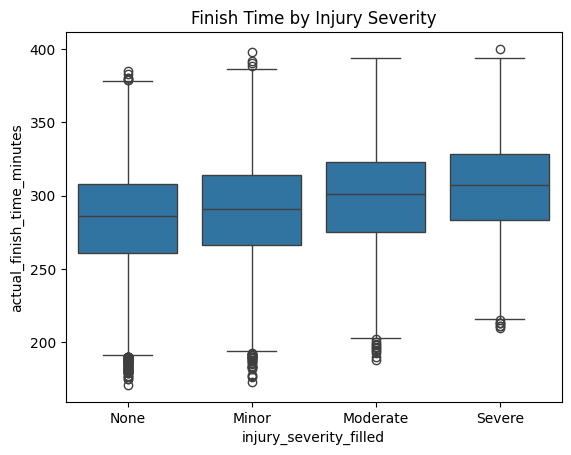

In [16]:
# Fill NaN as 'None' temporarily and compare finish times
train['injury_severity_filled'] = train['injury_severity'].fillna('None')

order = ['None', 'Minor', 'Moderate', 'Severe']
sns.boxplot(data=train, x='injury_severity_filled',
            y='actual_finish_time_minutes', order=order)
plt.title('Finish Time by Injury Severity')
plt.show()


In [17]:
# ============================================================
# EDA FINDINGS SUMMARY — based on confirmed outputs
# ============================================================

findings = """
=== DATASET OVERVIEW ===
- 80,000 runners in train, 20,000 in test, 41 features
- Target: actual_finish_time_minutes (range 171–400 min, mean ~288 min / 4h48)
- 1,989 missing actual_finish_time_minutes → DNFs (did not finish)

=== MISSING VALUES ===
- injury_severity: 47,350 missing (59%) → NaN means no injury, recode as 'None'
- personal_best_minutes: 10,745 missing → likely first-time marathoners
- vo2_max: 9,611 missing → not everyone gets lab tested
- cross_training, nutrition_score, hydration_consistency: moderate missingness (self-reported)
- sleep_hours_avg: 3,942 missing

=== CATEGORICAL FEATURES ===
- gender: Male ~48% / Female ~48% / Non-binary ~4%
  → Weak predictor — almost no difference in finish time across genders
- training_program: Beginner (50%) / Intermediate (32%) / Advanced (18%)
  → Strong ordinal predictor: Beginner ~310 / Intermediate ~280 / Advanced ~245 min
- marathon_weather: 6 categories, fairly balanced
  → Hot weather shows slightly higher finish times, minimal difference overall
- course_difficulty: Flat / Mixed / Hilly fairly balanced
  → Hilly courses show noticeably higher finish times than Flat
- marathon_date: finish time flat across all 12 months (~288 min)
  → Month/season is NOT a useful feature → drop it

=== NUMERIC FEATURES ===
- running_experience_months: strongest legitimate predictor (r=-0.65)
  → Strong non-linear negative relationship, most gains from 0–50 months
- speed_work_sessions_per_week (r=-0.35): more sessions = faster, clear step pattern
- runs_per_week (r=-0.31): more runs = faster, clear step pattern
- rest_days_per_week (r=+0.30): more rest = slower
- resting_heart_rate_bpm (r=+0.20): higher HR = slightly slower, noisy
- vo2_max (r=-0.35): higher VO2 max = meaningfully faster

=== INJURY SEVERITY ===
- Clear ordinal effect: None ~285 / Minor ~293 / Moderate ~305 / Severe ~310 min
- Encode ordinally as: None=0, Minor=1, Moderate=2, Severe=3

=== DNF ANALYSIS ===
- DNF runners are older (+2.4 yrs), less experienced (-8 months), more injuries (1.12 vs 0.54)
- Implication: drop DNFs from training set or model separately

=== LEAKY FEATURES — exclude from model ===
- target_finish_time_minutes (r=0.95) — runner's own pre-race goal
- personal_best_minutes (r=0.86) — use carefully, may leak
- medal_outcome (r=-0.38) — race outcome, not a predictor
- weekly_mileage_miles — exact duplicate of weekly_mileage_km

=== PREPROCESSING PLAN ===
1. Recode injury_severity NaN → 'None', encode ordinally (0–3)
2. Flag first-time marathoners where personal_best_minutes is NaN
3. Encode training_program ordinally (Beginner=0, Intermediate=1, Advanced=2)
4. OHE: marathon_weather, course_difficulty, gender
5. Drop: marathon_date, weekly_mileage_miles, target_finish_time_minutes, medal_outcome
6. Drop DNF rows (actual_finish_time_minutes is NaN)
7. Build baseline model (Linear Regression)
"""

print(findings)


=== DATASET OVERVIEW ===
- 80,000 runners in train, 20,000 in test, 41 features
- Target: actual_finish_time_minutes (range 171–400 min, mean ~288 min / 4h48)
- 1,989 missing actual_finish_time_minutes → DNFs (did not finish)

=== MISSING VALUES ===
- injury_severity: 47,350 missing (59%) → NaN means no injury, recode as 'None'
- personal_best_minutes: 10,745 missing → likely first-time marathoners
- vo2_max: 9,611 missing → not everyone gets lab tested
- cross_training, nutrition_score, hydration_consistency: moderate missingness (self-reported)
- sleep_hours_avg: 3,942 missing

=== CATEGORICAL FEATURES ===
- gender: Male ~48% / Female ~48% / Non-binary ~4%
  → Weak predictor — almost no difference in finish time across genders
- training_program: Beginner (50%) / Intermediate (32%) / Advanced (18%)
  → Strong ordinal predictor: Beginner ~310 / Intermediate ~280 / Advanced ~245 min
- marathon_weather: 6 categories, fairly balanced
  → Hot weather shows slightly higher finish times, m

In [18]:
# Copy
train_clean = train.copy()
test_clean = test.copy()

In [19]:
# Step 1 — Drop DNF rows (no finish time = can't train on them)
print(f"Before: {train_clean.shape}")
train_clean = train_clean.dropna(subset=['actual_finish_time_minutes'])
print(f"After dropping DNFs: {train_clean.shape}")

Before: (80000, 44)
After dropping DNFs: (78011, 44)


In [20]:
# Check remaining missing values after dropping DNFs
train_clean.isnull().sum().sort_values(ascending=False)

injury_severity                   46873
personal_best_minutes             10478
vo2_max                            9362
cross_training_hours_per_week      7783
hydration_consistency              6271
nutrition_score                    6255
sleep_hours_avg                    3840
run_club_attendance_rate              0
training_streak_days                  0
missed_workout_pct                    0
early_morning_run_frequency           0
weather_condition_training_pct        0
goal_completion_rate                  0
runner_id                             0
warmup_adherence_pct                  0
marathon_date                         0
marathon_weather                      0
course_difficulty                     0
target_finish_time_minutes            0
actual_finish_time_minutes            0
mental_preparation_score              0
medal_outcome                         0
dnf                                   0
month                                 0
stretching_adherence_pct              0


In [21]:
# Full list of features in the dataset
print(list(train_clean.columns))


['runner_id', 'age', 'gender', 'running_experience_months', 'previous_marathon_count', 'training_program', 'motivation_level', 'personal_best_minutes', 'weekly_mileage_km', 'weekly_mileage_miles', 'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week', 'rest_days_per_week', 'training_adherence_pct', 'consecutive_weeks_no_miss', 'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count', 'injury_severity', 'nutrition_score', 'hydration_consistency', 'training_streak_days', 'missed_workout_pct', 'early_morning_run_frequency', 'weather_condition_training_pct', 'goal_completion_rate', 'run_club_attendance_rate', 'warmup_adherence_pct', 'stretching_adherence_pct', 'marathon_date', 'marathon_weather', 'course_difficulty', 'target_finish_time_minutes', 'actual_finish_time_minutes', 'mental_preparation_score', 'medal_outcome', 'dnf', 'month', 'injury_severity_filled']


In [22]:
# Full list of features in a readable format
for i, col in enumerate(train_clean.columns, 1):
    print(f"{i:02d}. {col}")
    

01. runner_id
02. age
03. gender
04. running_experience_months
05. previous_marathon_count
06. training_program
07. motivation_level
08. personal_best_minutes
09. weekly_mileage_km
10. weekly_mileage_miles
11. runs_per_week
12. long_run_distance_km
13. speed_work_sessions_per_week
14. rest_days_per_week
15. training_adherence_pct
16. consecutive_weeks_no_miss
17. cross_training_hours_per_week
18. resting_heart_rate_bpm
19. vo2_max
20. bmi
21. recovery_score
22. sleep_hours_avg
23. injury_count
24. injury_severity
25. nutrition_score
26. hydration_consistency
27. training_streak_days
28. missed_workout_pct
29. early_morning_run_frequency
30. weather_condition_training_pct
31. goal_completion_rate
32. run_club_attendance_rate
33. warmup_adherence_pct
34. stretching_adherence_pct
35. marathon_date
36. marathon_weather
37. course_difficulty
38. target_finish_time_minutes
39. actual_finish_time_minutes
40. mental_preparation_score
41. medal_outcome
42. dnf
43. month
44. injury_severity_fill

In [23]:
!git add .
!git commit -m "My Notebook"
!git push origin HEAD:Francesco

[master c5b6103] My Notebook
 1 file changed, 217 insertions(+), 237 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 10 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 2.43 KiB | 113.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To github.com:francescosias/MarathonIQ.git
   32d7466..c5b6103  HEAD -> Francesco


In [24]:
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map = {"Minor": 1, "Moderate": 2, "Severe": 3}

In [46]:
# ── ENCODING ──────────────────────────────────────────────────────────────────

# 1. Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map   = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map   = {"Minor": 1, "Moderate": 2, "Severe": 3}

df['training_program']  = df['training_program'].map(training_map)
df['course_difficulty'] = df['course_difficulty'].map(course_map)
df['injury_severity']   = df['injury_severity'].map(injury_map).fillna(0)

# 2. Gender — ordinal binary (Male=0, Female=1, Non-binary=2)
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Non-binary': 2})

# 3. Nominal — one-hot encode only marathon_weather (gender already encoded above)
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df[['marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                       columns=ohe.get_feature_names_out(['marathon_weather']),
                       index=df.index)

df = df.drop(columns=['marathon_weather'])
df = pd.concat([df, ohe_df], axis=1)

# ── DROP LIST ─────────────────────────────────────────────────────────────────
drop_list = [
    "runner_id",
    "weekly_mileage_miles",
    "target_finish_time_minutes",
    "medal_outcome",
    "marathon_date",
          
    "personal_best_minutes",    # removing the leaky PB feature
]

df = df.drop(columns=[c for c in drop_list if c in df.columns])

KeyError: 'training_program'

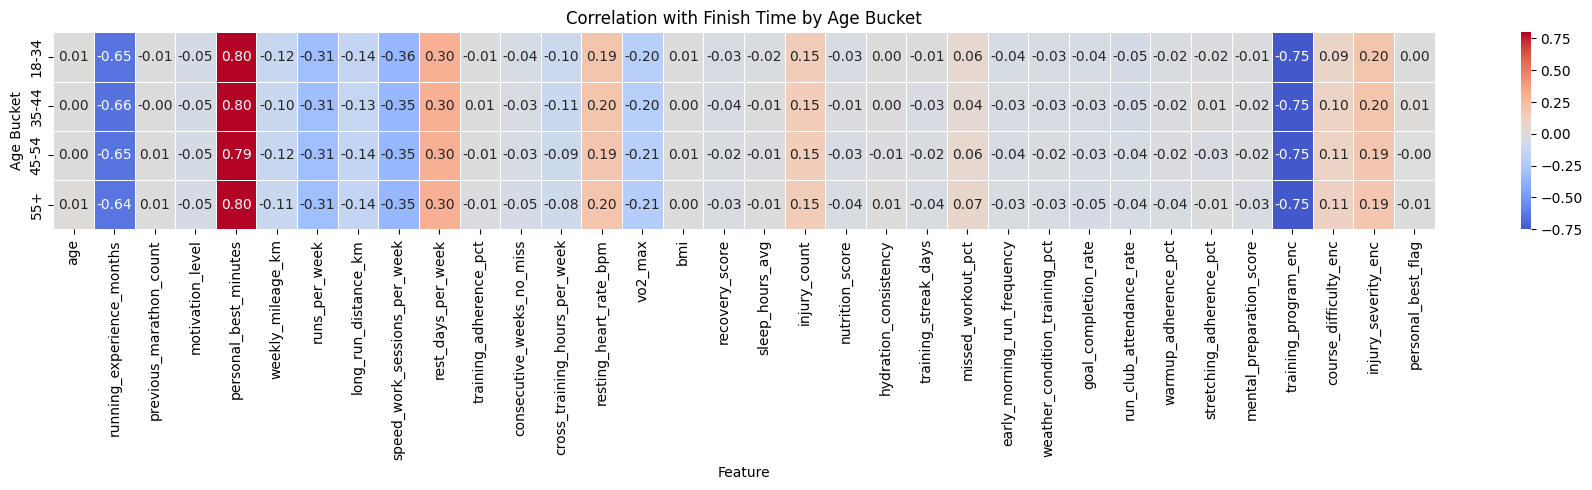

In [26]:
# Create age buckets based on marathon age categories
bins = [18, 35, 45, 55, 100]
labels = ['18-34', '35-44', '45-54', '55+']
train_clean['age_bucket'] = pd.cut(train_clean['age'], bins=bins, labels=labels, right=False)

# Correlation of numeric features with finish time, split by age bucket
numeric_cols = train_clean.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'actual_finish_time_minutes']

corr_by_age = (train_clean
               .groupby('age_bucket', observed=True)[numeric_cols + ['actual_finish_time_minutes']]
               .apply(lambda g: g.corr()['actual_finish_time_minutes'].drop('actual_finish_time_minutes'))
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(corr_by_age, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation with Finish Time by Age Bucket')
ax.set_xlabel('Feature')
ax.set_ylabel('Age Bucket')
plt.tight_layout()
plt.show()


In [27]:
cols_to_drop = ['dnf', 'weekly_mileage_miles', 'medal_outcome', 
                'target_finish_time_minutes', 'month', 'injury_severity_filled']

train_clean = train_clean.drop(columns=[c for c in cols_to_drop if c in train_clean.columns])

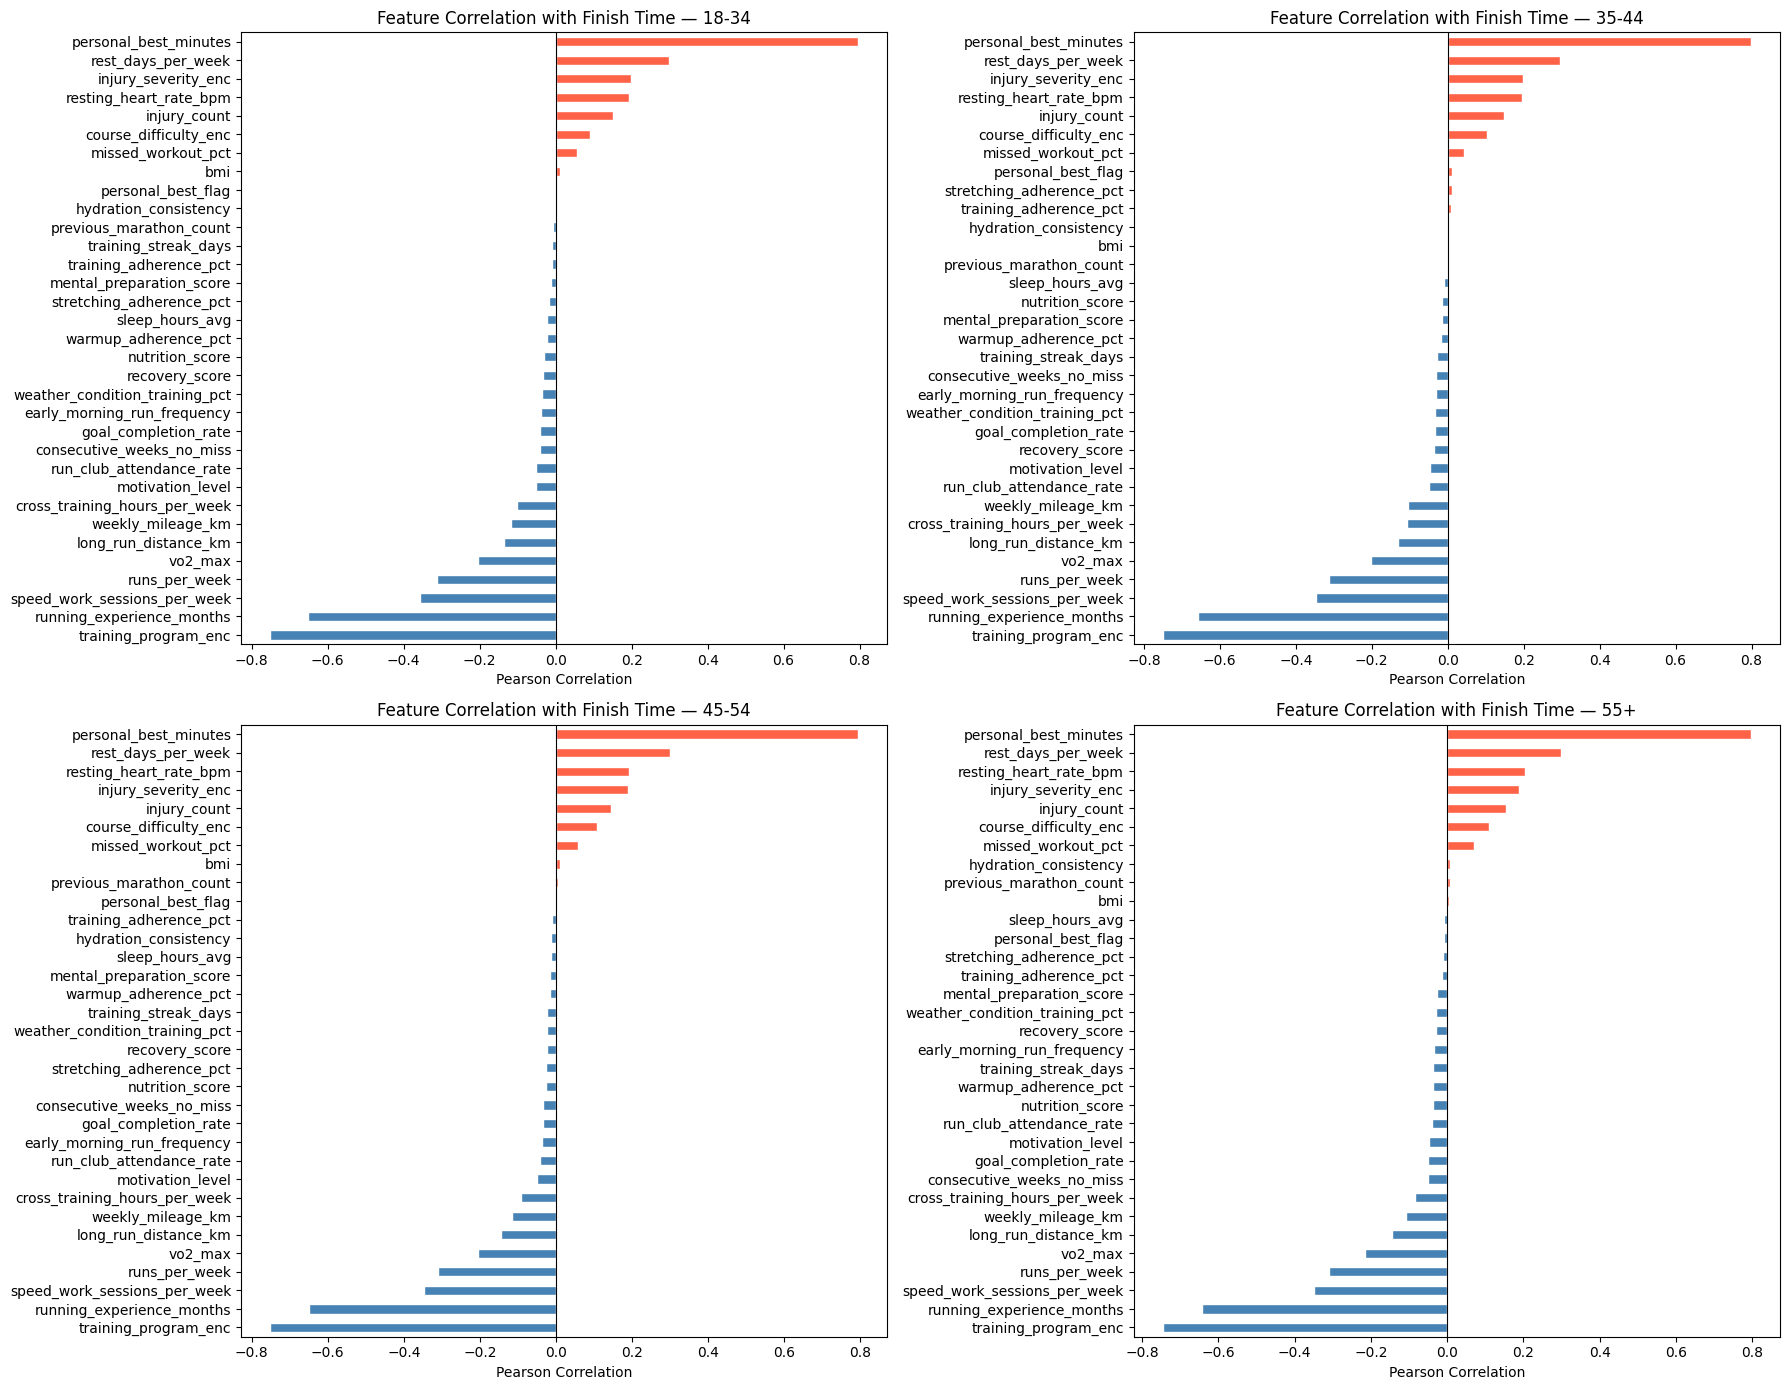

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

bins = [18, 35, 45, 55, 100]
labels = ['18-34', '35-44', '45-54', '55+']
train_clean['age_bucket'] = pd.cut(train_clean['age'], bins=bins, labels=labels, right=False)

for ax, bucket in zip(axes.flatten(), labels):
    subset = train_clean[train_clean['age_bucket'] == bucket]
    
    corr = (subset
            .select_dtypes(include='number')
            .corr()['actual_finish_time_minutes']
            .drop(['actual_finish_time_minutes', 'age'])
            .sort_values())
    
    colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature Correlation with Finish Time — {bucket}', fontsize=12)
    ax.set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# EDA FINDINGS — CORRELATION ANALYSIS BY SUBGROUP
# ============================================================

## BY AGE GROUP
# ------------------------------------------------------------
# CONSISTENT ACROSS ALL AGES:
# - running_experience_months → strongest negative predictor in every group
# - training_program_enc → strong negative predictor, stable across all ages
# - personal_best_minutes → strong positive (semi-leaky, use carefully)
# - rest_days_per_week → positive across all groups (more rest = slower)
#
# CHANGES WITH AGE:
# - resting_heart_rate_bpm: grows as a predictor with age
#   → worth adding interaction term: age × resting_heart_rate_bpm
# - injury_severity_enc + injury_count: increasingly important for older runners
#   → worth adding interaction term: age × injury_count
# - running_experience_months: weakens for 55+
#   → experience matters less when physical decline dominates
# - vo2_max: consistent but slightly weaker in 55+
#   → natural VO2 max decline reduces variance in older group
#
# SUGGESTED FEATURES BY AGE:
# 18-34 → running_experience_months, vo2_max, speed_work_sessions_per_week,
#          training_program_enc, runs_per_week
# 35-44 → same as 18-34 + resting_heart_rate_bpm starts to matter
# 45-54 → resting_heart_rate_bpm, injury_count, vo2_max,
#          training_program_enc, missed_workout_pct
# 55+   → injury_severity_enc, injury_count, resting_heart_rate_bpm,
#          training_program_enc, course_difficulty_enc

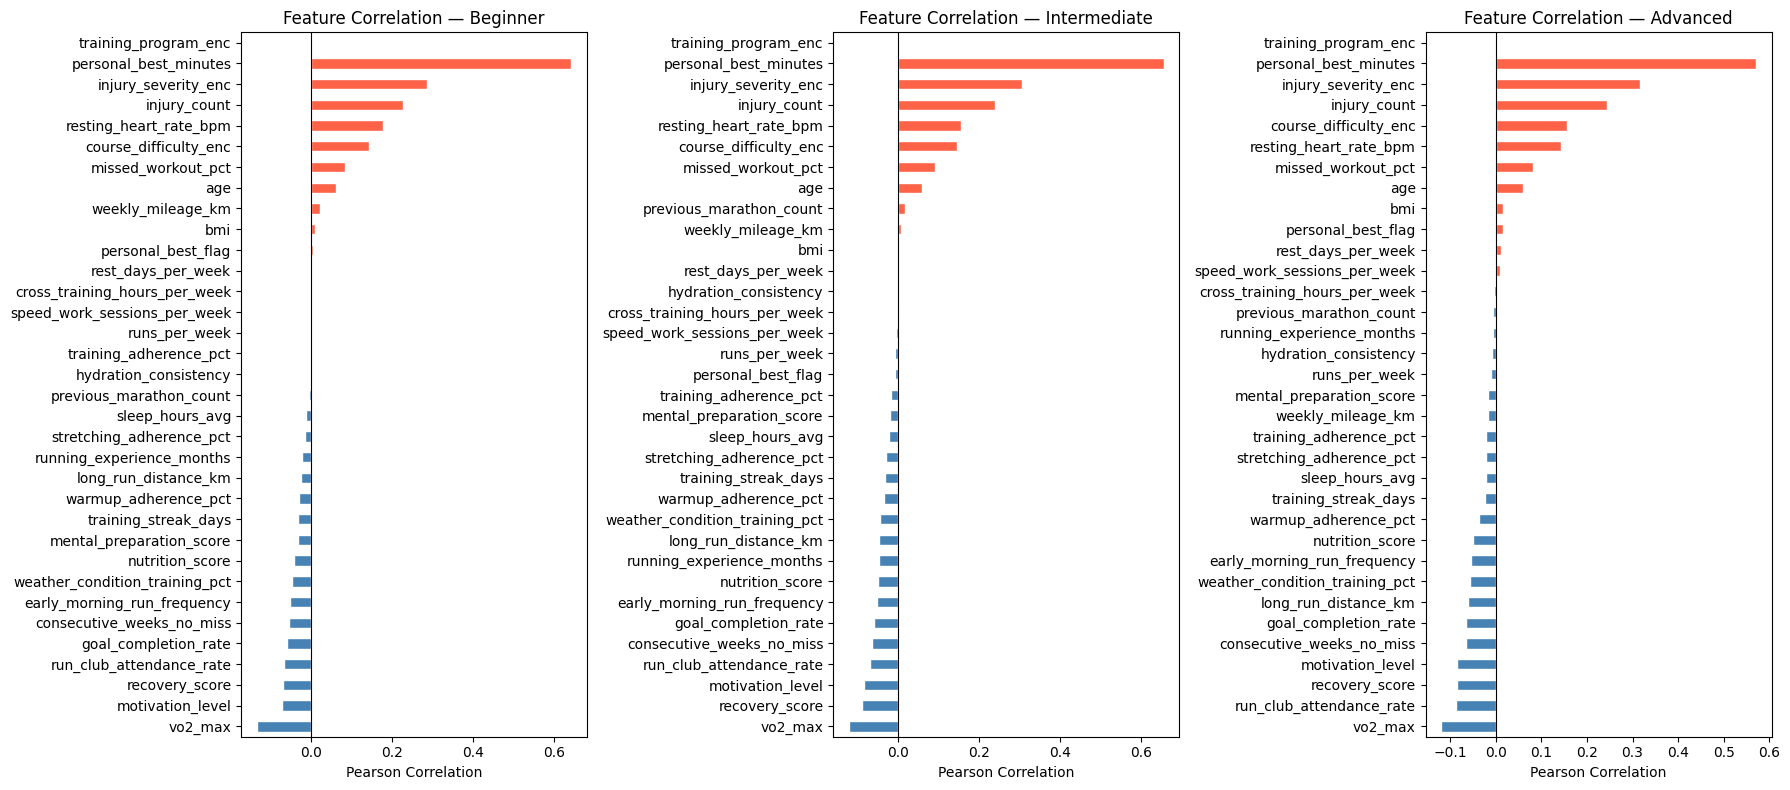

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, program in zip(axes.flatten(), ['Beginner', 'Intermediate', 'Advanced']):
    subset = train_clean[train_clean['training_program_enc'] == training_map[program]]
    
    corr = (subset
            .select_dtypes(include='number')
            .corr()['actual_finish_time_minutes']
            .drop(['actual_finish_time_minutes'])
            .sort_values())
    
    colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature Correlation — {program}', fontsize=12)
    ax.set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## BY TRAINING PROGRAM
# ------------------------------------------------------------
# BEGINNER:
# - vo2_max is the dominant negative predictor
#   → raw fitness is what separates runners when training is basic
# - running_experience_months has almost no effect
#   → experience without proper training doesn't translate to speed
#
# INTERMEDIATE:
# - More balanced: vo2_max, running_experience_months, speed_work_sessions_per_week
#   all contribute meaningfully
# - Transition zone — both fitness and training quality matter
#
# ADVANCED:
# - speed_work_sessions_per_week and running_experience_months dominate
# - vo2_max weakens — structured training compensates for lower aerobic capacity
#   → at elite level, training discipline > raw fitness
#
# SUGGESTED FEATURES BY TRAINING LEVEL:
# Beginner     → vo2_max, injury_count, missed_workout_pct, course_difficulty_enc
# Intermediate → vo2_max, running_experience_months, speed_work_sessions_per_week,
#                training_streak_days
# Advanced     → speed_work_sessions_per_week, running_experience_months,
#                long_run_distance_km, training_streak_days
#


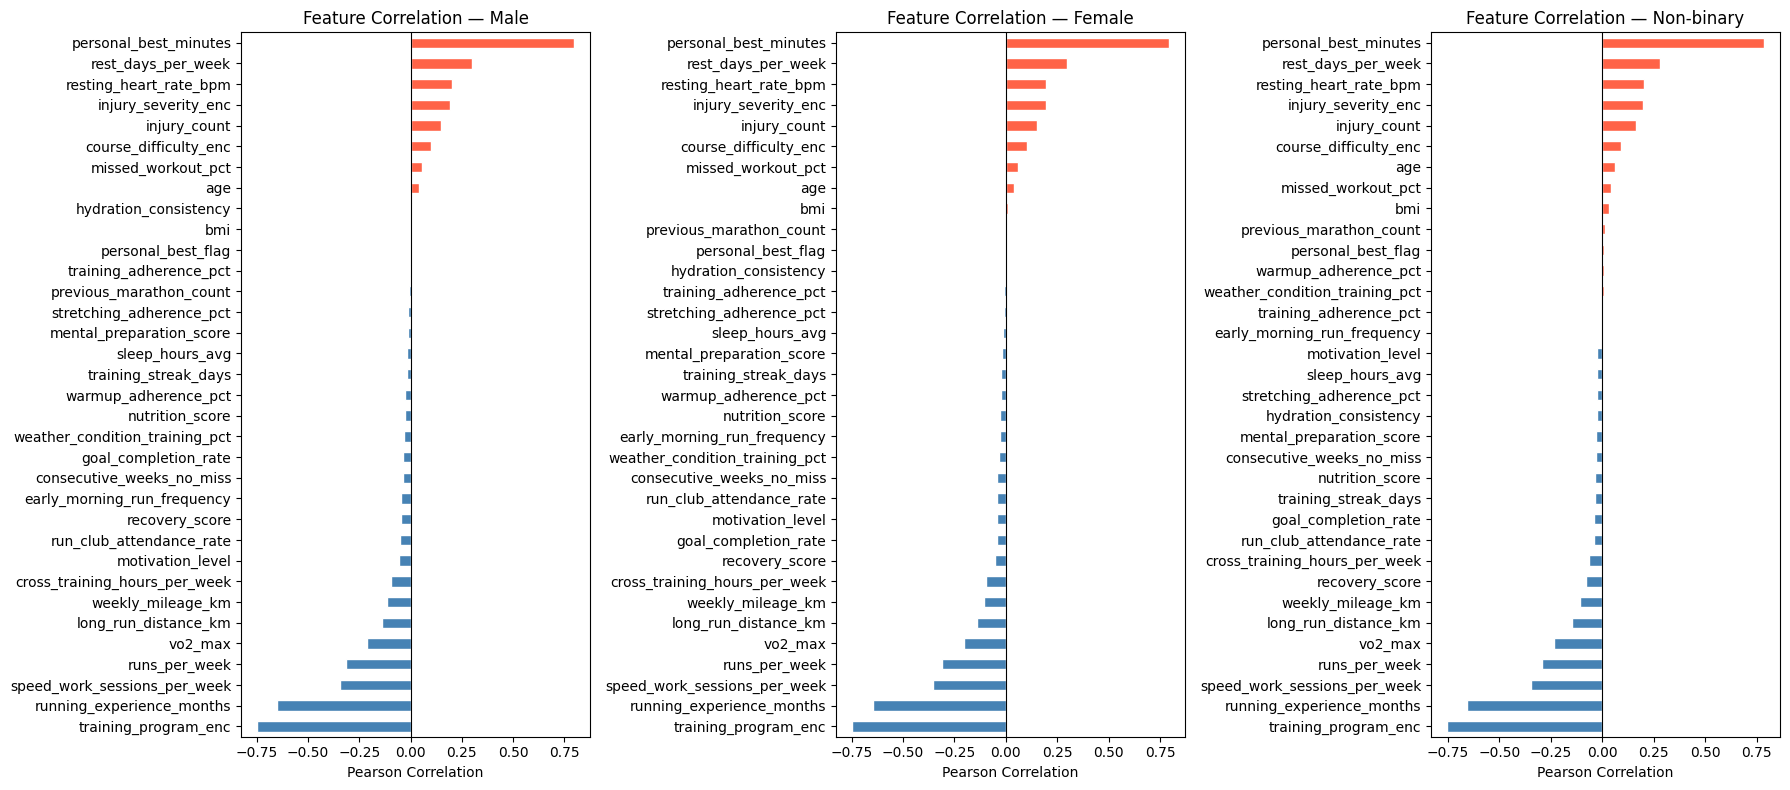

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, gender in zip(axes.flatten(), train_clean['gender'].unique()):
    subset = train_clean[train_clean['gender'] == gender]
    
    corr = (subset
            .select_dtypes(include='number')
            .corr()['actual_finish_time_minutes']
            .drop(['actual_finish_time_minutes'])
            .sort_values())
    
    colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Feature Correlation — {gender}', fontsize=12)
    ax.set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## BY GENDER
# ------------------------------------------------------------
# - Patterns are almost identical across Male, Female and Non-binary
# - running_experience_months and training_program_enc are top negative predictors
#   for all three groups
# - Non-binary group shows noisier correlations due to small sample size (~4%)
#
# CONCLUSION:
# → Gender is NOT a useful predictor — drop it from the model
# → Do NOT create gender interaction terms, no signal to exploit

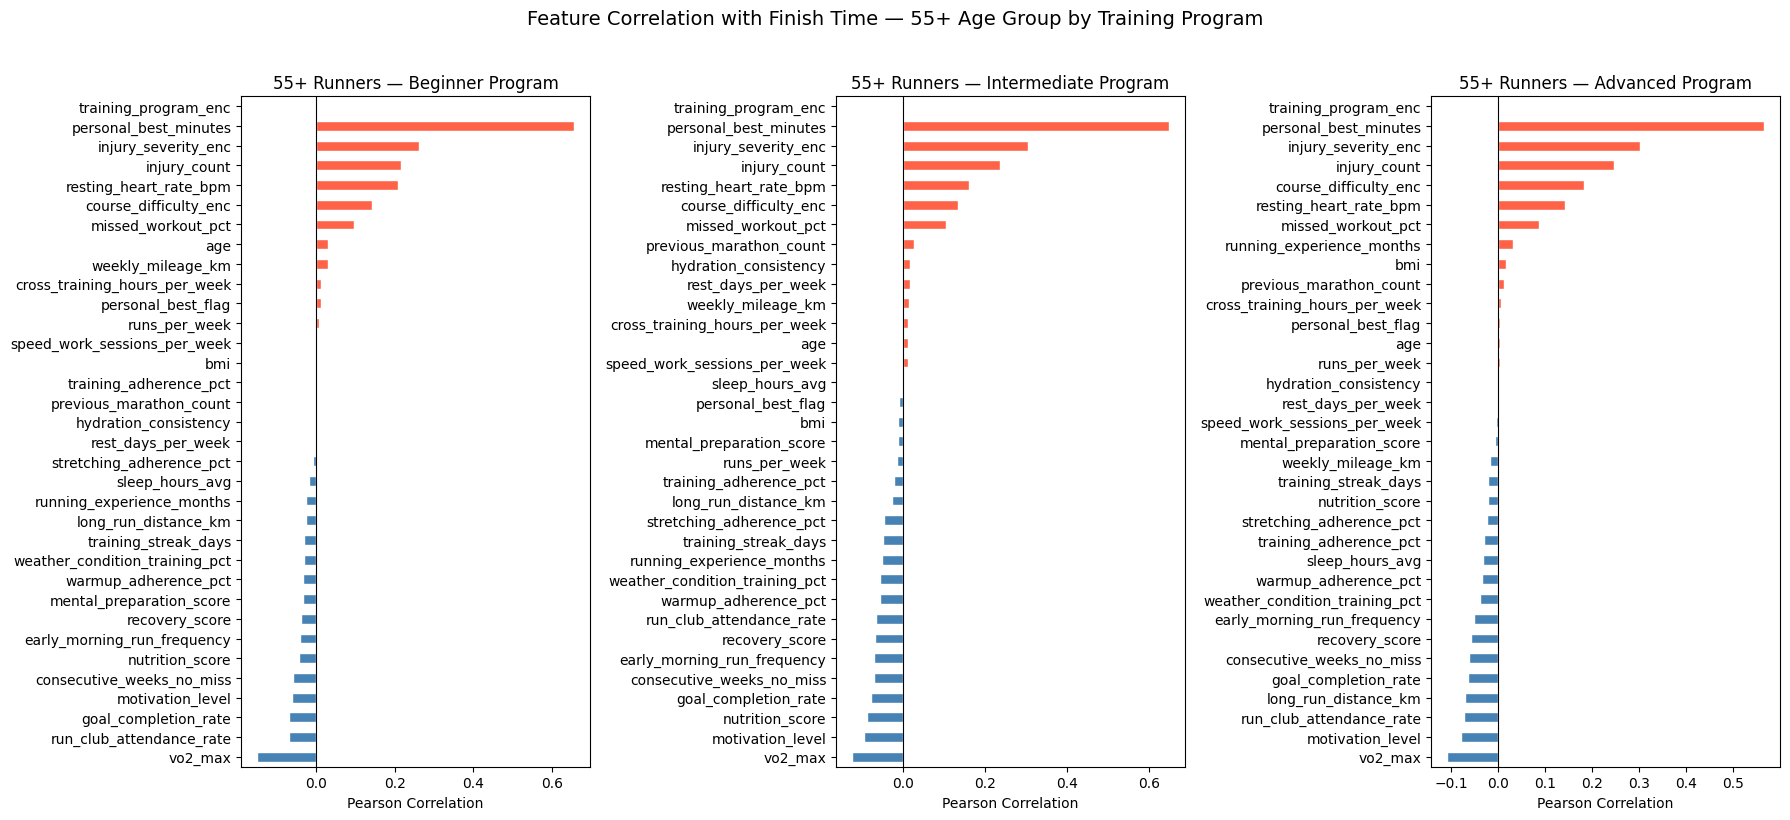

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

senior = train_clean[train_clean['age_bucket'] == '55+']

for ax, program in zip(axes.flatten(), ['Beginner', 'Intermediate', 'Advanced']):
    subset = senior[senior['training_program_enc'] == training_map[program]]
    
    corr = (subset
            .select_dtypes(include='number')
            .corr()['actual_finish_time_minutes']
            .drop(['actual_finish_time_minutes'])
            .sort_values())
    
    colors = ['steelblue' if v < 0 else 'tomato' for v in corr]
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'55+ Runners — {program} Program', fontsize=12)
    ax.set_xlabel('Pearson Correlation')

plt.suptitle('Feature Correlation with Finish Time — 55+ Age Group by Training Program', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
bins = [18, 35, 45, 55, 100]
labels = ['18-34', '35-44', '45-54', '55+']
train_clean['age_bucket'] = pd.cut(train_clean['age'], bins=bins, labels=labels, right=False)

df = train_clean.copy()

In [34]:
import warnings
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Filter to 55+ runners only
df_55 = df[df['age_bucket'] == '55+'].copy()

# Keep only numeric columns and drop target
X_55 = df_55.select_dtypes(include='number').drop(columns=['actual_finish_time_minutes'])
y_55 = df_55['actual_finish_time_minutes']

# Fill NaNs with median
X_55 = X_55.fillna(X_55.median())
X_55 = X_55.astype(np.float64)
y_55 = y_55.astype(np.float64)

# Pipeline: scale + Linear Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

scores = cross_val_score(pipeline, X_55, y_55, cv=5, scoring='neg_root_mean_squared_error')

print(f"55+ Linear Regression Baseline")
print(f"Features used: {X_55.shape[1]}")
print(f"RMSE per fold: {[-round(s, 2) for s in scores]}")
print(f"Mean RMSE:     {-scores.mean():.2f} min")
print(f"Std RMSE:      {scores.std():.2f} min")

55+ Linear Regression Baseline
Features used: 34
RMSE per fold: [np.float64(14.97), np.float64(14.96), np.float64(15.03), np.float64(14.74), np.float64(14.87)]
Mean RMSE:     14.91 min
Std RMSE:      0.10 min


In [35]:
import warnings
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Use full dataset
X = df.select_dtypes(include='number').drop(columns=['actual_finish_time_minutes'])
y = df['actual_finish_time_minutes']

# Fill NaNs with median
X = X.fillna(X.median())
X = X.astype(np.float64)
y = y.astype(np.float64)

# Pipeline: scale + Linear Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(f"Full Dataset — Linear Regression Baseline")
print(f"Runners: {X.shape[0]} | Features: {X.shape[1]}")
print(f"RMSE per fold: {[-round(s, 2) for s in scores]}")
print(f"Mean RMSE:     {-scores.mean():.2f} min")
print(f"Std RMSE:      {scores.std():.2f} min")

Full Dataset — Linear Regression Baseline
Runners: 78011 | Features: 34
RMSE per fold: [np.float64(14.87), np.float64(14.96), np.float64(14.88), np.float64(14.77), np.float64(14.79)]
Mean RMSE:     14.85 min
Std RMSE:      0.07 min


In [36]:
for i, col in enumerate(X.columns, 1):
    print(f"{i:02d}. {col}")
    

01. age
02. running_experience_months
03. previous_marathon_count
04. motivation_level
05. personal_best_minutes
06. weekly_mileage_km
07. runs_per_week
08. long_run_distance_km
09. speed_work_sessions_per_week
10. rest_days_per_week
11. training_adherence_pct
12. consecutive_weeks_no_miss
13. cross_training_hours_per_week
14. resting_heart_rate_bpm
15. vo2_max
16. bmi
17. recovery_score
18. sleep_hours_avg
19. injury_count
20. nutrition_score
21. hydration_consistency
22. training_streak_days
23. missed_workout_pct
24. early_morning_run_frequency
25. weather_condition_training_pct
26. goal_completion_rate
27. run_club_attendance_rate
28. warmup_adherence_pct
29. stretching_adherence_pct
30. mental_preparation_score
31. training_program_enc
32. course_difficulty_enc
33. injury_severity_enc
34. personal_best_flag


In [37]:
dropped = [col for col in df.columns if col not in X.columns]
print("Dropped columns:")
for col in dropped:
    print(f"  - {col}")

Dropped columns:
  - runner_id
  - gender
  - actual_finish_time_minutes
  - marathon_weather_Cold
  - marathon_weather_Hot
  - marathon_weather_Rainy
  - marathon_weather_Sunny
  - marathon_weather_Windy
  - age_bucket


In [38]:
!pip install xgboost

In [44]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def run_model(model, df, age_bucket=None, scale=False):
    
    # Filter by age group or use full dataset
    subset = df[df['age_bucket'] == age_bucket].copy() if age_bucket else df.copy()
    
    # Build X (numeric features only) and y (target)
    X = (subset
         .select_dtypes(include='number')
         .drop(columns=['actual_finish_time_minutes'])
         .fillna(subset.median(numeric_only=True)))
    y = subset['actual_finish_time_minutes']
    
    # Wrap in pipeline with scaler for linear models
    estimator = Pipeline([('scaler', StandardScaler()), ('model', model)]) if scale else model
    
    # 5-fold cross validation for RMSE, MAE and R²
    rmse_scores = cross_val_score(estimator, X, y, cv=5, scoring='neg_root_mean_squared_error')
    mae_scores  = cross_val_score(estimator, X, y, cv=5, scoring='neg_mean_absolute_error')
    r2_scores   = cross_val_score(estimator, X, y, cv=5, scoring='r2')
    
    # Print results
    label = f"{type(model).__name__} — {age_bucket or 'Full dataset'}"
    print(f"{label}:")
    print(f"  RMSE: {-rmse_scores.mean():.2f} min | Std: {rmse_scores.std():.2f}")
    print(f"  MAE:  {-mae_scores.mean():.2f} min  | Std: {mae_scores.std():.2f}")
    print(f"  R²:   {r2_scores.mean():.4f}     | Std: {r2_scores.std():.4f}")
    print()

run_model(LinearRegression(), df, scale=True)
run_model(LinearRegression(), df, age_bucket='55+', scale=True)

LinearRegression — Full dataset:
  RMSE: 14.85 min | Std: 0.07
  MAE:  11.50 min  | Std: 0.03
  R²:   0.8051     | Std: 0.0016

LinearRegression — 55+:
  RMSE: 14.91 min | Std: 0.10
  MAE:  11.52 min  | Std: 0.08
  R²:   0.8023     | Std: 0.0033

